In [2]:
import pandas as pd
import numpy as np

import sys
sys.path.append('../')
from Data.dataset import AstroDataset

import matplotlib.pyplot as plt

# Dataset class, drop apod.nasa.gov

In [14]:
nasa = pd.read_csv('../Data/apod_clean_urls.csv')
print(nasa.shape)
# nasa.head()

(10708, 19)


In [4]:
import os

In [6]:
files = os.listdir('../astro-images')
files[3]

'4773.png'

In [7]:
import skimage

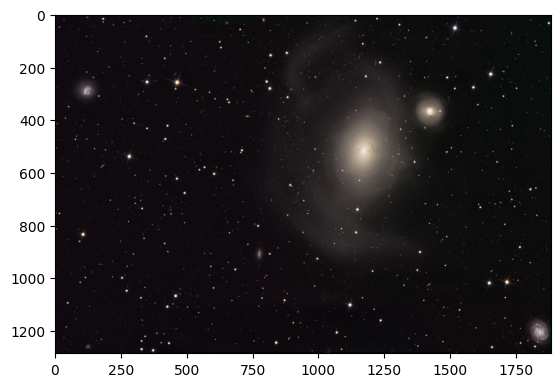

In [9]:
im = skimage.io.imread('../astro-images/4773.png')
plt.imshow(im)

In [15]:
nasa.iloc[4773]

Unnamed: 0                                                        4798
date                                                        2008-09-03
explanation          On July 4th, 2005, the Deep Impact spacecraft ...
hdurl                https://apod.nasa.gov/apod/image/0809/epoxi4pa...
media_type                                                       image
service_version                                                     v1
title                               31 Million Miles from Planet Earth
url                  https://apod.nasa.gov/apod/image/0809/epoxi4pa...
copyright                                                          NaN
year                                                              2008
month                                                                9
weekday                                                      Wednesday
explanation_clean    On July 4th, 2005, the Deep Impact spacecraft ...
expl_word_count                                                    149
expl_c

In [4]:
import requests
from PIL import Image
from io import BytesIO

def _fetch_image(url):
    response = requests.get(url, timeout=10)
    response.raise_for_status()
    img = Image.open(BytesIO(response.content))
    if hasattr(img, 'n_frames') and img.n_frames > 1:  # handle GIFs
        img.seek(0)
    return img.convert("RGB")

In [21]:
nasa.loc[0, 'hdurl']

'https://apod.nasa.gov/apod/image/e_lens.gif'

In [5]:
from tqdm import tqdm

In [6]:
url_index = []
for i in tqdm(range(1000)):
    url = nasa.loc[i, 'hdurl']
    try:
        img = _fetch_image(url)
    except:
        url_index.append(i)

100%|██████████| 1000/1000 [05:58<00:00,  2.79it/s]


- Save first 1000 images, no need to use all of them for training. Just for faster screening.

In [7]:
url_index

[601]

In [8]:
nasa = nasa.drop(index=601)[:1000]

In [10]:
nasa.loc[1000, 'hdurl']

'https://apod.nasa.gov/apod/image/9804/qso0157_hst.gif'

In [11]:
img = _fetch_image(nasa.loc[1000, 'hdurl'])

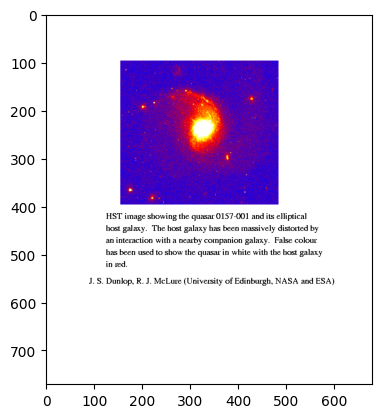

In [13]:
plt.imshow(img)

In [16]:
import numpy as np

np.random.seed(42)
n = len(nasa)
idx = np.random.permutation(n)

train_end = int(0.70 * n)
val_end   = int(0.85 * n)

split = np.empty(n, dtype=object)
split[idx[:train_end]]      = 'train'
split[idx[train_end:val_end]] = 'val'
split[idx[val_end:]]        = 'test'

nasa['split'] = split

In [18]:
nasa[nasa.split == 'train'].shape

(700, 19)

In [19]:
nasa.to_csv('../Data/apod_1000.csv')

In [9]:
dataset = AstroDataset(df=nasa)

torch.Size([3, 224, 224])
In the Sahara Desert in Egypt lie the oldest known astronomically aligned stones in the world: Nabta. Over one thousand years before the creation of Stonehenge, local herders built a stone circle and other structures on the shoreline of a lake that has long since dried up.  Over 6000 years ago, stone slabs three meters high were dragged over a kilometer to create the site.  Shown above is one of the stones that remains.  Little is known about the ultimate purpose of  Nabta and the nature of the people who built it.


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

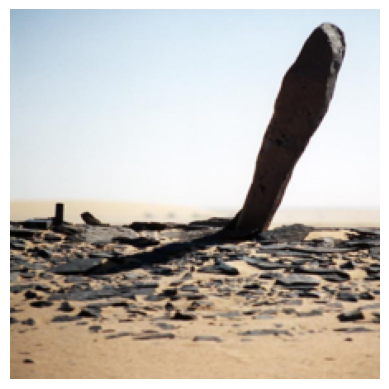

In [10]:
im, text = dataset[1000]
print(im.shape)
print(text)
plt.imshow(im.permute(1,2,0))
plt.axis('off')

## Dataloader class

In [11]:
from torch.utils.data import DataLoader

In [12]:
loader = DataLoader(
    dataset=dataset,
    batch_size=32,
    shuffle=True
)

In [13]:
item = next(iter(loader))
imgs, texts = item
print(imgs.shape)
print(len(texts))

torch.Size([32, 3, 224, 224])
32


# Test Flow

In [2]:
from nflows.flows import Flow
from nflows.distributions.normal import StandardNormal
from nflows.transforms.base import CompositeTransform
from nflows.transforms.normalization import ActNorm
from nflows.transforms.coupling import AffineCouplingTransform
from nflows.transforms.permutations import ReversePermutation
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModel
import numpy as np
from tqdm import tqdm

In [ ]:
class TextEncoder(nn.Module):
    def __init__(self, model_name="bert-base-uncased", out_dim=128):
        super().__init__()
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.encoder   = AutoModel.from_pretrained(model_name)
        for p in self.encoder.parameters():
            p.requires_grad = False
        self.proj = nn.Linear(768, out_dim)

    def forward(self, texts):
        tokens = self.tokenizer(
            texts, padding=True, truncation=True,
            max_length=64, return_tensors="pt"
        ).to(next(self.proj.parameters()).device)
        with torch.no_grad():
            out = self.encoder(**tokens).last_hidden_state[:, 0] # cls token
        return self.proj(out)                


def make_net(in_features, out_features, cond_dim):
    return nn.Sequential(
        nn.Linear(in_features + cond_dim, 256),
        nn.ReLU(),
        nn.Linear(256, 256),
        nn.ReLU(),
        nn.Linear(256, out_features),
    )


class ConditionalFlow(nn.Module):
    def __init__(self, img_dim=224*224*3, cond_dim=128, n_layers=4):
        super().__init__()
        self.img_dim  = img_dim
        self.cond_dim = cond_dim

        # Flatten image → 1D, then project down to a tractable dim
        self.img_proj   = nn.Linear(img_dim, 512)
        self.img_unproj = nn.Linear(512, img_dim)
        flow_dim = 512

        transforms_list = []
        for _ in range(n_layers):
            transforms_list += [
                ActNorm(flow_dim),
                ReversePermutation(features=flow_dim),
                AffineCouplingTransform(
                    mask=torch.arange(flow_dim) % 2, 
                    transform_net_create_fn=lambda in_f, out_f: make_net(in_f, out_f, cond_dim=self.cond_dim), # the network that estimates affine transformation parameters
                ),
            ]

        self.flow = Flow(
            transform=CompositeTransform(transforms_list),
            distribution=StandardNormal([flow_dim]),
        )


    def log_prob(self, images, context):
        """images: [B, C, H, W], context: [B, cond_dim]"""
        x = images.view(images.size(0), -1) 
        x = self.img_proj(x)
        return self.flow.log_prob(x, context=context)

    @torch.no_grad()
    def sample(self, n, context):
        x = self.flow.sample(n, context=context)   # [n, 512]
        x = self.img_unproj(x)                     # [n, img_dim]
        return x.view(n, 3, 224, 224).clamp(0, 1)
    

def train(df, epochs=10, batch_size=32, lr=1e-4, device="cuda"):
    device = torch.device(device if torch.cuda.is_available() else "cpu")

    # Dataset & loader  (your AstroDataset returns (image_tensor, text_string))
    dataset = AstroDataset(df)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    text_enc = TextEncoder(out_dim=128).to(device)
    flow = ConditionalFlow(img_dim=224*224*3, cond_dim=128, n_layers=4).to(device)

    optimizer = torch.optim.Adam(
        list(flow.parameters()) + list(text_enc.proj.parameters()), lr=lr
    )

    for epoch in tqdm(range(epochs)):
        total_loss = 0.0
        for images, texts in loader:
            images = images.to(device)
            texts = list(texts)           # tuple → list of strings

            context = text_enc(texts)      # [B, 128]
            loss = -flow.log_prob(images, context).mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}  loss={total_loss/len(loader):.4f}")

    return flow, text_enc


@torch.no_grad()
def generate(flow, text_enc, prompt, n=4, device="cuda"):
    context = text_enc([prompt] * n)       # repeat prompt for n samples
    samples = flow.sample(n, context)      # [n, 3, 224, 224]
    return samples

In [11]:
train(df=nasa)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
  0%|          | 0/10 [00:13<?, ?it/s]


KeyboardInterrupt: 